<a href="https://colab.research.google.com/github/lucianotadeu/foto_para_stl_3D/blob/main/foto_para_stl_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Foto → Modelo 3D → STL imprimível (Google Colab)

**Versão 4** Uma foto entra, um STL pronto para o fatiador sai, com visualização 3D no próprio notebook e um app web opcional para apresentar ao vivo.

**Gerador:** [Hunyuan3D-2mini](https://huggingface.co/tencent/Hunyuan3D-2mini) (Tencent), só a parte de *geometria*.

### Por que esta versão funciona e as anteriores não
| Problema das versões antigas | O que esta faz |
|---|---|
| TRELLIS precisa de `spconv`, `vox2seq` e kernels compilados que não existem para o Python 3.13 do Colab | Nada é compilado: tudo é Python puro + PyTorch que já vem no Colab |
| TripoSR não é instalável via `pip` (`git clone` falhava) e depende de `torchmcubes` compilado | O pacote `hy3dgen` é instalado direto do **PyPI** |
| Células reinstalavam `torch`/`Pillow` e quebravam o ambiente | **Nunca** mexe no `torch`; se o pip atualizar Pillow/NumPy, o notebook reinicia sozinho uma vez |
| Chamadas de API erradas (`target_count`, argumentos do `pymeshfix`) | Parte de reparo testada com malhas quebradas |

### Antes de começar
1. `Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4` (ou L4).
2. **Importante:** como as versões anteriores desinstalaram o PyTorch, comece limpo: `Ambiente de execução → Desconectar e excluir ambiente de execução`.
3. Rode as células **em ordem**, de cima para baixo.

| Etapa | T4 (1ª vez) | T4 (depois) |
|---|---|---|
| Instalação | ~2 min | segundos |
| Download dos pesos (3,8 GB) | 1–3 min | já em disco |
| Geração 3D (qualidade *normal*) | ~1–2 min | ~1–2 min |
| Reparo + STL | < 30 s | < 30 s |

> As mensagens vermelhas `ERROR: pip's dependency resolver...` citando `cudf`, `numba`, `pytensor` etc. são **avisos sobre pacotes do Colab que não usamos**. Não são o erro. A célula de instalação diz explicitamente se algo realmente falhou.

## Passo 1 — Conferir a GPU

In [ ]:
import subprocess
r = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                   capture_output=True, text=True)
if r.returncode != 0:
    raise SystemExit("Sem GPU. Vá em Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4. "
                     "Sem GPU, use o Plano B no fim do notebook.")
print("GPU encontrada:", r.stdout.strip())

GPU encontrada: Tesla T4, 15360 MiB


## Passo 2 — Instalar (sem compilar nada)

Esta célula não importa nenhuma biblioteca pesada no kernel: instala, testa a importação em um processo separado e, **se o pip tiver atualizado Pillow/NumPy/SciPy**, reinicia o ambiente automaticamente.

Se aparecer *"Sua sessão falhou"* ou *"reiniciada"* logo depois, **é esperado**: rode esta célula de novo (vai levar segundos) e siga para o Passo 3.

In [ ]:
import os, sys, subprocess
from importlib import metadata

def versao(pacote):
    try:
        return metadata.version(pacote)
    except metadata.PackageNotFoundError:
        return None

if versao("torch") is None or versao("torchvision") is None:
    raise SystemExit("torch/torchvision não estão instalados (uma versão antiga do notebook os removeu).\n"
                     "Faça: Ambiente de execução → Desconectar e excluir ambiente de execução, e rode tudo de novo.")

SENSIVEIS = ["pillow", "numpy", "scipy", "scikit-image", "transformers", "torch"]
antes = {p: versao(p) for p in SENSIVEIS}

def pip_install(*pacotes):
    print("instalando:", " ".join(pacotes))
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pacotes], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-4000:]); print(r.stderr[-4000:])
        raise SystemExit("A instalação acima falhou de verdade (não é só aviso).")

# biblioteca de sistema que o pymeshlab (usado pelo hy3dgen) procura
subprocess.run("apt-get -qq install -y libopengl0 > /dev/null 2>&1", shell=True)

# 1) gerador 3D: pacote oficial do PyPI, sem dependências de interface (gradio/fastapi) nem compilação
pip_install("--no-deps", "hy3dgen==2.0.2")
# 2) dependências de fato usadas na geração de geometria e no reparo da malha
pip_install("transformers>=4.48", "diffusers", "accelerate", "einops", "omegaconf", "pyyaml", "safetensors",
            "huggingface_hub", "pymeshlab", "pygltflib", "trimesh", "pymeshfix", "fast-simplification",
            "rembg", "onnxruntime")
if not any(versao(p) for p in ["opencv-python", "opencv-python-headless", "opencv-contrib-python"]):
    pip_install("opencv-python-headless")

# 3) teste de importação em processo separado (não contamina o kernel)
teste = subprocess.run([sys.executable, "-c",
    "from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline\n"
    "from hy3dgen.rembg import BackgroundRemover\n"
    "import trimesh, pymeshfix, fast_simplification, torch\n"
    "assert torch.cuda.is_available(), 'torch não enxerga a GPU'\n"
    "print('importações OK | torch', torch.__version__)"],
    capture_output=True, text=True)
print(teste.stdout.strip())
if teste.returncode != 0:
    print(teste.stderr[-4000:])
    raise SystemExit("Teste de importação falhou. Copie a mensagem acima.")

depois = {p: versao(p) for p in SENSIVEIS}
mudou = {p: (antes[p], depois[p]) for p in SENSIVEIS if antes[p] != depois[p]}
if mudou:
    print("\nVersões atualizadas pelo pip:", mudou)
    print(">>> Reiniciando o ambiente para carregar as versões novas. Rode ESTA célula mais uma vez e siga para o Passo 3.")
    os.kill(os.getpid(), 9)
else:
    print("\nTudo pronto. Siga para o Passo 3.")

instalando: --no-deps hy3dgen==2.0.2
instalando: transformers>=4.48 diffusers accelerate einops omegaconf pyyaml safetensors huggingface_hub pymeshlab pygltflib trimesh pymeshfix fast-simplification rembg onnxruntime
importações OK | torch 2.11.0+cu128

Tudo pronto. Siga para o Passo 3.


## Passo 3 — Baixar os pesos e carregar o modelo

Baixa só o necessário (config + `model.fp16.safetensors`, 3,8 GB) — o carregador padrão baixaria 7,6 GB.

In [ ]:
import os, time, torch
os.environ["HY3DGEN_MODELS"] = "/content/modelos"
os.makedirs("/content/saida", exist_ok=True)

from huggingface_hub import hf_hub_download
REPO, SUBPASTA = "tencent/Hunyuan3D-2mini", "hunyuan3d-dit-v2-mini"
for arquivo in ["config.yaml", "model.fp16.safetensors"]:
    hf_hub_download(REPO, f"{SUBPASTA}/{arquivo}", local_dir=f"/content/modelos/{REPO}")

from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline
from hy3dgen.rembg import BackgroundRemover

DISPOSITIVO = "cuda"
t0 = time.time()
pipeline = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(
    REPO, subfolder=SUBPASTA, use_safetensors=True, device=DISPOSITIVO)
removedor_fundo = BackgroundRemover()
print(f"modelo carregado em {time.time() - t0:.0f} s")

config.yaml:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

hunyuan3d-dit-v2-mini/model.fp16.safeten(…): reconstructing file:   0%|          |  0.00B / 3.82GB            

hunyuan3d-dit-v2-mini/model.fp16.safeten(…): downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
2026-09-17 22:02:50,176 - hy3dgen.shapgen - INFO - Try to load model from local path: /content/modelos/tencent/Hunyuan3D-2mini/hunyuan3d-dit-v2-mini
INFO:hy3dgen.shapgen:Try to load model from local path: /content/modelos/tencent/Hunyuan3D-2mini/hunyuan3d-dit-v2-mini
2026-09-17 22:02:50,183 - hy3dgen.shapgen - INFO - Loading model from /content/modelos/tencent/Hunyuan3D-2mini/hunyuan3d-dit-v2-mini/model.fp16.safetensors
INFO:hy3dgen.shapgen:Loading model from /content/modelos/tencent/Hunyuan3D-2mini/hunyuan3d-dit-v2-mini/model.fp16.safetensors


  0%|                                              | 0.00/1.02G [00:00<?, ?B/s]

modelo carregado em 58 s


## Passo 4 — Enviar a foto

**Foto boa:** um objeto só, inteiro no quadro, fundo liso, luz difusa, ângulo de ~3/4. Foto de celular serve.
**Foto ruim:** vários objetos, objeto cortado pela borda, vidro/espelho, sombra dura.

Se o botão de upload não aparecer ou der erro (acontece em alguns navegadores), arraste a foto para o painel **Arquivos** (ícone de pasta à esquerda), dentro de `/content`, e rode a célula de novo — ela usa a imagem mais recente que encontrar. Também dá para preencher `FOTO` com o caminho.

Saving caixa_1.jpg to caixa_1.jpg
foto: /content/caixa_1.jpg (1024, 1024)


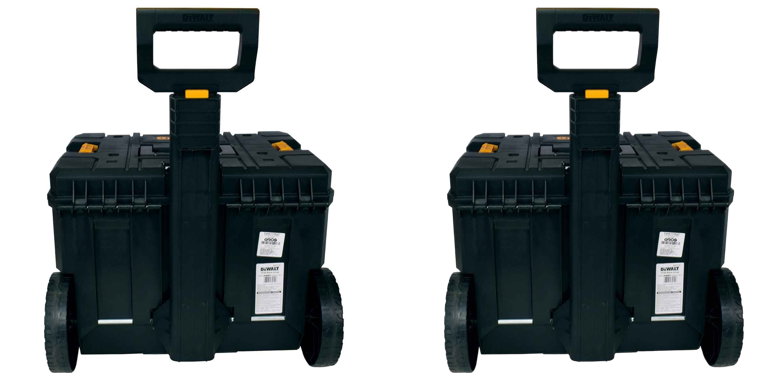

In [ ]:
import os, glob, numpy as np
from PIL import Image, ImageOps

FOTO = ""   # opcional: ex. "/content/minha_foto.jpg"
EXTENSOES = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".avif")

def obter_foto():
    if FOTO:
        if not os.path.exists(FOTO):
            raise SystemExit(f"Arquivo não encontrado: {FOTO}")
        return FOTO
    try:
        from google.colab import files
        enviados = files.upload()          # grava o arquivo em /content
    except Exception as e:
        print("upload pelo botão indisponível:", e)
        enviados = None
    if enviados:
        return os.path.join("/content", os.path.basename(list(enviados)[0]))
    candidatas = [p for p in glob.glob("/content/**/*", recursive=True)
                  if p.lower().endswith(EXTENSOES) and "/saida/" not in p and "/modelos/" not in p]
    if not candidatas:
        raise SystemExit("Nenhuma foto encontrada. Arraste uma imagem para o painel Arquivos e rode de novo.")
    return max(candidatas, key=os.path.getmtime)

def lado_a_lado(a, b, altura=384):
    a = a.convert("RGBA"); b = b.convert("RGBA")
    a = a.resize((int(a.width * altura / a.height), altura)); b = b.resize((int(b.width * altura / b.height), altura))
    tela = Image.new("RGBA", (a.width + b.width + 16, altura), (255, 255, 255, 255))
    tela.paste(a, (0, 0), a); tela.paste(b, (a.width + 16, 0), b)
    return tela.convert("RGB")

caminho_foto = obter_foto()
foto = ImageOps.exif_transpose(Image.open(caminho_foto))   # corrige rotação de fotos de celular
foto.thumbnail((1024, 1024))

if 'removedor_fundo' not in globals():
    print("Carregando removedor_fundo (pois o Passo 3 estava incompleto)...")
    from hy3dgen.rembg import BackgroundRemover
    removedor_fundo = BackgroundRemover()

ja_transparente = foto.mode == "RGBA" and np.asarray(foto.getchannel("A")).min() < 250
sem_fundo = foto if ja_transparente else removedor_fundo(foto.convert("RGB"))
if sem_fundo.getchannel("A").getbbox() is None:
    raise SystemExit("A remoção de fundo não encontrou nenhum objeto. Tente outra foto.")

print("foto:", caminho_foto, foto.size)
display(lado_a_lado(foto, sem_fundo))

## Passo 5 — Gerar o modelo 3D

`QUALIDADE`: `"rapida"` (bom para testar/apresentar), `"normal"` (padrão recomendado pela Tencent), `"alta"` (use em L4/A100).
Se a forma sair estranha, **troque a `SEED`** antes de trocar a foto.

In [ ]:
import time, torch

QUALIDADE = "normal"   # "rapida" | "normal" | "alta"
SEED = 1234

PRESETS = {
    "rapida": dict(num_inference_steps=20, octree_resolution=256),
    "normal": dict(num_inference_steps=30, octree_resolution=380),
    "alta":   dict(num_inference_steps=50, octree_resolution=512),
}

def gerar_malha(imagem_rgba, qualidade=QUALIDADE, seed=SEED):
    try:
        resultado = pipeline(image=imagem_rgba, generator=torch.manual_seed(seed), num_chunks=20000,
                             output_type="trimesh", **PRESETS[qualidade])
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        raise SystemExit('Memória da GPU insuficiente. Use QUALIDADE = "rapida".')
    malha = resultado[0] if isinstance(resultado, (list, tuple)) else resultado
    if malha is None or len(malha.faces) == 0:
        raise SystemExit("O modelo não gerou superfície. Troque a SEED ou a foto.")
    return malha

t0 = time.time()
malha_bruta = gerar_malha(sem_fundo)
CAMINHO_GLB = "/content/saida/bruto.glb"
malha_bruta.export(CAMINHO_GLB)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"gerado em {time.time() - t0:.0f} s | {len(malha_bruta.faces):,} faces -> {CAMINHO_GLB}")

Volume Decoding: 100%|██████████| 2766/2766 [01:32<00:00, 29.79it/s]


gerado em 105 s | 1,258,348 faces -> /content/saida/bruto.glb


## Passo 6 — Ver em 3D (gire com o mouse)

In [ ]:
import base64, io, html, numpy as np, trimesh
from IPython.display import HTML

def visualizar_3d(malha, z_para_cima=False, max_faces=60_000, altura_px=460):
    """Visualizador interativo (<model-viewer> do Google) com a malha embutida no notebook."""
    m = malha.copy()
    if len(m.faces) > max_faces:
        try:
            m = m.simplify_quadric_decimation(face_count=max_faces)
        except Exception:
            pass
    if z_para_cima:   # STL usa Z para cima; glTF usa Y para cima
        m.apply_transform(trimesh.transformations.rotation_matrix(-np.pi / 2, [1, 0, 0]))
    m.visual = trimesh.visual.ColorVisuals(m, face_colors=[205, 170, 120, 255])
    glb = m.export(file_type="glb")
    src = "data:model/gltf-binary;base64," + base64.b64encode(glb).decode()
    pagina = f"""<!doctype html><html><head>
<script type="module" src="https://cdn.jsdelivr.net/npm/@google/model-viewer@4.0.0/dist/model-viewer.min.js"></script>
</head><body style="margin:0;background:#f3f3f3">
<model-viewer src="{src}" camera-controls auto-rotate shadow-intensity="1" exposure="1.1"
  style="width:100%;height:{altura_px - 10}px"></model-viewer></body></html>"""
    return HTML(f'<iframe srcdoc="{html.escape(pagina)}" style="width:100%;height:{altura_px}px;border:0"></iframe>')

display(visualizar_3d(malha_bruta))

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


---
# Parte 3 — Malha → STL imprimível

Malha gerada por IA quase nunca vai direto para a impressora. Esta parte:
1. junta tudo em uma malha só e remove faces degeneradas/duplicadas;
2. descarta pedaços soltos (mantém o maior corpo);
3. reduz polígonos para o fatiador não engasgar;
4. fecha buracos e corrige geometria não-manifold com **pymeshfix**;
5. acerta normais, **gira de Y-para-cima (IA) para Z-para-cima (fatiador)**, escala em milímetros e apoia em Z = 0.

In [ ]:
import numpy as np, trimesh

def carregar_malha(caminho):
    """Lê GLB/OBJ/PLY/STL e devolve UMA malha (achata cenas com várias partes)."""
    obj = trimesh.load(caminho)
    if isinstance(obj, trimesh.Scene):
        partes = [g for g in obj.dump() if isinstance(g, trimesh.Trimesh) and len(g.faces)]
        if not partes:
            raise ValueError("O arquivo não contém nenhuma malha.")
        obj = trimesh.util.concatenate(partes)
    return trimesh.Trimesh(vertices=np.asarray(obj.vertices), faces=np.asarray(obj.faces), process=True)

def reparar_para_impressao(m, alvo_faces=200_000, log=print):
    m = trimesh.Trimesh(vertices=np.asarray(m.vertices), faces=np.asarray(m.faces), process=True)
    log(f"entrada: {len(m.faces):,} faces | fechada={m.is_watertight}")
    m.update_faces(m.nondegenerate_faces())
    m.update_faces(m.unique_faces())
    m.remove_unreferenced_vertices()
    m.merge_vertices()
    partes = m.split(only_watertight=False)
    if len(partes) > 1:
        m = max(partes, key=lambda p: len(p.faces))
        log(f"{len(partes)} corpos soltos -> mantido o maior ({len(m.faces):,} faces)")
    if len(m.faces) > alvo_faces:
        try:
            m = m.simplify_quadric_decimation(face_count=int(alvo_faces))
            log(f"reduzida para {len(m.faces):,} faces")
        except Exception as e:
            log(f"redução ignorada: {e}")
    if not m.is_watertight:
        import pymeshfix
        mf = pymeshfix.MeshFix(np.asarray(m.vertices, dtype=np.float64), np.asarray(m.faces, dtype=np.int32))
        mf.repair(joincomp=False, remove_smallest_components=True)
        m = trimesh.Trimesh(vertices=mf.points, faces=mf.faces, process=True)
        log(f"pymeshfix: {len(m.faces):,} faces | fechada={m.is_watertight}")
    trimesh.repair.fix_normals(m, multibody=False)
    if m.is_watertight and m.volume < 0:
        m.invert()
    return m

def orientar_e_escalar(m, altura_mm=80.0, eixo_vertical="y"):
    if eixo_vertical == "y":
        m.apply_transform(trimesh.transformations.rotation_matrix(np.pi / 2, [1, 0, 0]))
    m.apply_scale(altura_mm / m.extents[2])
    m.apply_translation([-m.bounds[:, 0].mean(), -m.bounds[:, 1].mean(), -m.bounds[0, 2]])
    return m

def relatorio(m):
    fechada = bool(m.is_watertight)
    vol_cm3 = float(m.volume) / 1000.0 if fechada else None
    return {
        "faces": f"{len(m.faces):,}",
        "fechada (watertight)": "SIM" if fechada else "NÃO",
        "normais consistentes": "SIM" if m.is_winding_consistent else "NÃO",
        "dimensões X × Y × Z (mm)": " × ".join(f"{v:.1f}" for v in m.extents),
        "volume (cm³)": f"{vol_cm3:.1f}" if fechada else "—",
        "PLA maciço 100% (g)": f"{vol_cm3 * 1.24:.0f}" if fechada else "—",
    }

print("funções de reparo carregadas")

funções de reparo carregadas


### Ajuste e rode
- `ALTURA_MM`: altura final da peça. Confira a mesa da sua impressora (ex.: Ender-5 Plus 350 × 350 × 400 mm).
- `ALVO_FACES`: 100–250 mil é a faixa saudável.
- `EIXO_VERTICAL`: `"y"` para malhas de IA (padrão). Se a peça aparecer **deitada** no visualizador abaixo, troque para `"z"`.

In [ ]:
ALTURA_MM = 80.0
ALVO_FACES = 200_000
EIXO_VERTICAL = "y"
CAMINHO_GLB = globals().get("CAMINHO_GLB", "/content/saida/bruto.glb")
CAMINHO_STL = "/content/saida/peca.stl"

peca = carregar_malha(CAMINHO_GLB)
peca = reparar_para_impressao(peca, alvo_faces=ALVO_FACES)
peca = orientar_e_escalar(peca, altura_mm=ALTURA_MM, eixo_vertical=EIXO_VERTICAL)
peca.export(CAMINHO_STL)

print("\nRELATÓRIO")
for chave, valor in relatorio(peca).items():
    print(f"  {chave:<28} {valor}")
print("\nSTL salvo em", CAMINHO_STL)
if not peca.is_watertight:
    print("\nATENÇÃO: a peça não ficou fechada. Gere de novo com outra SEED (Passo 5) — malha ruim se refaz, não se conserta.")

display(visualizar_3d(peca, z_para_cima=True))

entrada: 1,258,348 faces | fechada=True
7 corpos soltos -> mantido o maior (1,255,318 faces)
reduzida para 200,000 faces
pymeshfix: 199,866 faces | fechada=True

RELATÓRIO
  faces                        199,866
  fechada (watertight)         SIM
  normais consistentes         SIM
  dimensões X × Y × Z (mm)     65.3 × 63.7 × 80.0
  volume (cm³)                 129.0
  PLA maciço 100% (g)          160

STL salvo em /content/saida/peca.stl


In [ ]:
from google.colab import files
files.download(CAMINHO_STL)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Modo apresentação (opcional) — app web com link público

Cria uma página com **upload da foto → modelo 3D girando → botão de download do STL**. O Colab mostra o app aqui embaixo e também um link `https://....gradio.live` que funciona no celular ou no projetor por até 72 h (enquanto o notebook estiver rodando).

Precisa dos Passos 1–3 e da célula de funções da Parte 3.

In [ ]:
import subprocess, sys, tempfile, time, numpy as np, trimesh
from importlib import metadata
try:
    metadata.version("gradio")
except metadata.PackageNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=True)
import gradio as gr
from PIL import ImageOps

def app_processar(imagem, altura_mm, qualidade, seed, progress=gr.Progress()):
    if imagem is None:
        raise gr.Error("Envie uma foto primeiro.")
    t0 = time.time()
    progress(0.05, desc="Removendo fundo")
    imagem = ImageOps.exif_transpose(imagem); imagem.thumbnail((1024, 1024))
    rgba = removedor_fundo(imagem.convert("RGB"))
    progress(0.2, desc="Gerando geometria 3D")
    try:
        bruta = gerar_malha(rgba, qualidade=qualidade, seed=int(seed))
    except SystemExit as e:
        raise gr.Error(str(e))
    progress(0.8, desc="Reparando para impressão")
    peca_app = orientar_e_escalar(reparar_para_impressao(bruta, alvo_faces=200_000, log=lambda *a: None),
                                  altura_mm=float(altura_mm))
    pasta = tempfile.mkdtemp()
    stl = f"{pasta}/peca_{int(altura_mm)}mm.stl"; peca_app.export(stl)
    vis = peca_app.copy(); vis.apply_transform(trimesh.transformations.rotation_matrix(-np.pi / 2, [1, 0, 0]))
    glb = f"{pasta}/preview.glb"; vis.export(glb)
    r = relatorio(peca_app)
    resumo = (f"**Tempo:** {time.time() - t0:.0f} s  \n**Fechada:** {r['fechada (watertight)']}  \n"
              f"**Dimensões:** {r['dimensões X × Y × Z (mm)']} mm  \n**PLA maciço:** {r['PLA maciço 100% (g)']} g")
    return rgba, glb, stl, resumo

with gr.Blocks(title="Foto para 3D") as demo:
    gr.Markdown("## Foto → Modelo 3D → STL\nEnvie a foto de um objeto e receba um arquivo pronto para a impressora 3D.")
    with gr.Row():
        with gr.Column():
            entrada = gr.Image(type="pil", label="Foto")
            altura = gr.Slider(20, 300, value=80, step=5, label="Altura da peça (mm)")
            qualidade = gr.Radio(["rapida", "normal"], value="rapida", label="Qualidade")
            seed = gr.Number(value=1234, precision=0, label="Seed (troque se a forma sair estranha)")
            botao = gr.Button("Gerar 3D", variant="primary")
        with gr.Column():
            recorte = gr.Image(label="Fundo removido", height=220)
            modelo = gr.Model3D(label="Modelo 3D", clear_color=[0.95, 0.95, 0.95, 1.0], height=360)
            arquivo = gr.File(label="STL para download")
            info = gr.Markdown()
    botao.click(app_processar, [entrada, altura, qualidade, seed], [recorte, modelo, arquivo, info])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e34513277362c2e407.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
# Plano B — sem GPU no Colab (ou cota esgotada)

1. Abra um Space oficial no navegador, envie a foto e baixe o **GLB**:
   - [tencent/Hunyuan3D-2](https://huggingface.co/spaces/tencent/Hunyuan3D-2)
   - [tencent/Hunyuan3D-2.1](https://huggingface.co/spaces/tencent/Hunyuan3D-2.1)
   - [tencent/Hunyuan3D-2mini-Turbo](https://huggingface.co/spaces/tencent/Hunyuan3D-2mini-Turbo)
2. Rode a célula abaixo (funciona em CPU) e depois as células da **Parte 3** (funções → ajuste e rode → download). Pule o visualizador se preferir.

In [ ]:
import os, glob, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "trimesh", "pymeshfix", "fast-simplification"], check=True)
os.makedirs("/content/saida", exist_ok=True)
try:
    from google.colab import files
    enviados = files.upload()
except Exception as e:
    print("upload pelo botão indisponível:", e); enviados = None
if enviados:
    CAMINHO_GLB = os.path.join("/content", os.path.basename(list(enviados)[0]))
else:
    modelos = [p for p in glob.glob("/content/*") if p.lower().endswith((".glb", ".obj", ".ply", ".stl"))]
    if not modelos:
        raise SystemExit("Arraste o .glb para o painel Arquivos (/content) e rode de novo.")
    CAMINHO_GLB = max(modelos, key=os.path.getmtime)
print("usando:", CAMINHO_GLB)

---
## Se algo der errado

| Sintoma | Causa | O que fazer |
|---|---|---|
| `No module named 'torchvision'` ou `torch` | Notebook antigo desinstalou o PyTorch | Desconectar e excluir ambiente de execução; rodar do Passo 1 |
| Vermelho com `cudf`, `numba`, `pytensor` | Aviso sobre pacotes do Colab | Ignorar |
| Sessão reiniciou no Passo 2 | Reinício automático proposital | Rodar o Passo 2 de novo e seguir |
| `OutOfMemoryError` no Passo 5 | GPU pequena | `QUALIDADE = "rapida"` |
| Forma distorcida / buracos grandes | Foto ou seed ruins | Trocar `SEED`; foto com fundo liso e objeto inteiro |
| Botão de upload com `TypeError: 'NoneType'` | Widget bloqueado pelo navegador | Arrastar a foto para o painel Arquivos e rodar a célula de novo |
| Peça deitada no visualizador final | Eixo diferente | `EIXO_VERTICAL = "z"` |
| Fechada = NÃO | Malha muito ruim | Gerar de novo; o reparo não faz milagre |

## Alternativas open source (e por que não são o padrão aqui)

| Modelo | Qualidade de forma | Roda no Colab T4 sem compilar? | Observação |
|---|---|---|---|
| **Hunyuan3D-2mini** (usado) | Muito boa | **Sim** (PyPI `hy3dgen`) | Licença *tencent-hunyuan-community* |
| Hunyuan3D-2.1 | Melhor | Não trivial | Instalação pelo GitHub, mais VRAM; ótimo via Space |
| TRELLIS (Microsoft, MIT) | Muito boa | **Não** | `spconv`/kernels sem wheels para Python 3.13 — foi o que quebrou |
| TripoSR (MIT) | Razoável | **Não** | Sem `pip install`; depende de `torchmcubes` compilado |

## Licença
Os pesos Hunyuan3D-2mini usam a licença **tencent-hunyuan-community**: não vale na UE, Reino Unido e Coreia do Sul e tem condições para uso comercial em grande escala. Leia o arquivo `LICENSE` do repositório antes de vender peças.

## No fatiador
Oriente a maior face plana para a mesa, rode o verificador de malha, use suporte em árvore e faça a primeira peça em rascunho (0,28 mm, 10%). IA gera forma, não tolerância: para encaixes e peças funcionais, continue usando CAD.